# 10 - Feature importance (SHAP, regression-GBM decomposition, late class, reduced-feature robustness)

Looks at what the final tuned XGBoost model actually relies on:

1. Grouped SHAP ranking - additive feature attribution, summed across correlated feature families.
2. Regression-GBM decomposition - `pred_lateness_gbm` dominates the classifier's ranking; this breaks it down into the raw features it's built from.
3. Late-class SHAP: caught vs. missed - among actually-late trains, what differs between the ones the model flags and the ones it misses.
4. Reduced-feature robustness - dropping most of the feature set down to the top 40 barely moves any metric, showing the extra features carry little independent signal.

## Setup: load the cached final model

Loads `09d`'s cached stacked feature, fitted XGBoost classifier, and regression GBM (`reg_full`, the model that produces the stacked feature) instead of rebuilding from scratch. Falls back to rebuilding if the cache is missing.

In [1]:
import time as _time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import (
    roc_auc_score, average_precision_score, r2_score, mean_absolute_error,
)
import xgboost as xgb

from utils import (
    load_model_split, prep_gbm_matrices, GBM_FEATURES, GBM_CAT_FEATURES,
)

BASEPATH = "../data"

# temporary progress instrumentation -- claude
PROGRESS_LOG = "/tmp/10_progress.log"

def log_progress(msg):
    ts = _time.strftime("%H:%M:%S")
    line = f"[{ts}] {msg}"
    print(line)
    with open(PROGRESS_LOG, "a") as f:
        f.write(line + "\n")

log_progress("10_feature_importance.ipynb started")

train_df, test_df = load_model_split(BASEPATH)

# kept for complete cases to match every other notebook
logit_predictor_cols = [
    "line", "wx_primary_asof_collapsed", "temp_c_asof",
    "wind_speed_ms_asof", "precip_mm_asof", "any_gust_24h",
    "any_ice_24h", "has_cloud_layer", "am_peak_overlap_bin",
    "pm_peak_x_sports", "day_of_week", "is_holiday",
    "sched_duration_sec", "is_inbound", "lag_line_lateness_min",
    "lag_network_lateness_2hr_mean", "lag_train_lateness_5run_mean",
]

# 2024 held out as val, everything before goes to train_sub
VAL_YEAR = 2024
train_sub = train_df[train_df["year"] < VAL_YEAR].copy()
val_df = train_df[train_df["year"] == VAL_YEAR].copy()

# _cc = complete case: no missing values in any logit predictor column
val_mask = val_df[logit_predictor_cols].notna().all(axis = 1)
test_mask = test_df[logit_predictor_cols].notna().all(axis = 1)
val_cc = val_df[val_mask].copy()
test_cc = test_df[test_mask].copy()
y_val_cc = val_cc["is_otp"]
y_test_cc = test_cc["is_otp"]

print(f"train_sub: {train_sub.shape}, test: {test_cc.shape}")

/Users/stkath/MSE Data Science/DATS_5990_departure_prediction/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[15:32:06] 10_feature_importance.ipynb started


train_sub: (1170530, 107), test: (125836, 107)


In [2]:
import os
import joblib

TUNED_REG_PARAMS = dict(
    min_samples_leaf = 10, max_leaf_nodes = 127, max_iter = 500,
    max_depth = 7, learning_rate = 0.03, l2_regularization = 1,
)
TUNED_XGB_PARAMS = dict(
    subsample = 1.0, reg_lambda = 2, n_estimators = 400,
    min_child_weight = 3, max_depth = 7, learning_rate = 0.03,
    colsample_bytree = 0.6,
)

STACKED_FEATURES = GBM_FEATURES + ["pred_lateness_gbm"]

_cache_path = f"{BASEPATH}/9_pred_lateness_gbm_cached.parquet"
_model_path = f"{BASEPATH}/9d_final_xgb_model.joblib"
_reg_model_path = f"{BASEPATH}/9_reg_gbm_model.joblib"

# fast path -- everything below is already cached by 09d
if os.path.exists(_cache_path) and os.path.exists(_model_path):
    log_progress("Loading cached stacked feature + final XGBoost model...")
    _t0 = _time.time()
    stacked_cache = pd.read_parquet(_cache_path)
    train_sub = train_sub.join(
        stacked_cache[stacked_cache["split"] == "train_sub"]
        [["pred_lateness_gbm"]]
    )
    val_df = val_df.join(
        stacked_cache[stacked_cache["split"] == "val"][["pred_lateness_gbm"]]
    )
    test_df = test_df.join(
        stacked_cache[stacked_cache["split"] == "test"][["pred_lateness_gbm"]]
    )
    val_cc = val_df[val_mask].copy()
    test_cc = test_df[test_mask].copy()

    gbm = joblib.load(_model_path)
    reg_full = joblib.load(_reg_model_path)
    X_train_sub_stacked, X_test_stacked = prep_gbm_matrices(
        train_sub, test_df,
        features = STACKED_FEATURES, cat_features = GBM_CAT_FEATURES,
    )
    p_otp_test = gbm.predict_proba(X_test_stacked)[:, 1][test_mask.values]
    log_progress(f"Cache loaded ({_time.time() - _t0:.1f}s)")
# fallback -- rebuild the stacked feature and refit XGBoost from scratch
else:
    log_progress(
        "Cache not found -- rebuilding from scratch "
        "(see 09d for the cached version)"
    )
    X_train_sub_gbm, X_val_gbm = prep_gbm_matrices(train_sub, val_df)
    _, X_test_gbm_base = prep_gbm_matrices(train_sub, test_df)
    y_train_sub_log = np.log1p(train_sub["lateness"])

    _t0 = _time.time()
    log_progress(
        "Rebuilding out-of-fold stacked lateness feature on "
        "train_sub (5-fold KFold)..."
    )
    # out-of-fold so train_sub's own stacked feature is never fit on itself
    kf = KFold(n_splits = 5, shuffle = True, random_state = 42)
    oof_pred_lateness = np.zeros(len(train_sub))
    kf_splits = enumerate(kf.split(X_train_sub_gbm), start = 1)
    for fold, (tr_idx, val_idx) in kf_splits:
        fold_reg = HistGradientBoostingRegressor(
            categorical_features = "from_dtype", random_state = 42,
            **TUNED_REG_PARAMS
        )
        fold_reg.fit(
            X_train_sub_gbm.iloc[tr_idx], y_train_sub_log.iloc[tr_idx]
        )
        oof_pred_lateness[val_idx] = np.expm1(
            fold_reg.predict(X_train_sub_gbm.iloc[val_idx])
        )
        log_progress(f"  fold {fold}/5 done")

    train_sub["pred_lateness_gbm"] = oof_pred_lateness
    # refit on all of train_sub for the honest val/test predictions
    reg_full = HistGradientBoostingRegressor(
        categorical_features = "from_dtype", random_state = 42,
        **TUNED_REG_PARAMS
    )
    reg_full.fit(X_train_sub_gbm, y_train_sub_log)
    val_df["pred_lateness_gbm"] = np.expm1(reg_full.predict(X_val_gbm))
    test_df["pred_lateness_gbm"] = np.expm1(reg_full.predict(X_test_gbm_base))
    val_cc = val_df[val_mask].copy()
    test_cc = test_df[test_mask].copy()
    log_progress(f"Stacked feature rebuilt ({_time.time() - _t0:.1f}s total)")

    X_train_sub_stacked, X_test_stacked = prep_gbm_matrices(
        train_sub, test_df,
        features = STACKED_FEATURES, cat_features = GBM_CAT_FEATURES,
    )
    _t0 = _time.time()
    log_progress("Fitting tuned XGBoost (train_sub)...")
    gbm = xgb.XGBClassifier(
        random_state = 42, enable_categorical = True,
        tree_method = "hist", **TUNED_XGB_PARAMS
    )
    gbm.fit(X_train_sub_stacked, train_sub["is_otp"])
    p_otp_test = gbm.predict_proba(X_test_stacked)[:, 1][test_mask.values]
    log_progress(f"Tuned XGBoost fit complete ({_time.time() - _t0:.1f}s)")

baseline_roc_auc = roc_auc_score(y_test_cc, p_otp_test)
baseline_pr_auc_late = average_precision_score(1 - y_test_cc, 1 - p_otp_test)
print(
    f"baseline (unpermuted) -- roc_auc: {baseline_roc_auc:.4f}, "
    f"pr_auc_late: {baseline_pr_auc_late:.4f}"
)

[15:32:09] Loading cached stacked feature + final XGBoost model...


[15:32:10] Cache loaded (1.2s)
baseline (unpermuted) -- roc_auc: 0.8045, pr_auc_late: 0.6103


## 1. SHAP setup

SHAP's fast method only works in log-odds units, not probability (0-100%) units -- and the probability-unit option doesn't work with this model's categorical columns. So SHAP values are computed in log-odds space, then converted to probability units with a standard rescaling (multiplying by `p * (1 - p)`, each row's own predicted probability) so the numbers match the rest of the report.

Sample: 1000 rows, stratified by `is_otp` so the late class stays well represented.

In [3]:
SHAP_SAMPLE_N = 1000
sample_frac = SHAP_SAMPLE_N / len(test_cc)
shap_sample_cc = (
    test_cc.groupby("is_otp", group_keys = False)[test_cc.columns]
    .apply(lambda g: g.sample(frac = sample_frac, random_state = 42))
)
print(
    f"SHAP sample: {shap_sample_cc.shape}, "
    f"is_otp rate: {shap_sample_cc['is_otp'].mean():.4f} "
    f"(full test_cc rate: {test_cc['is_otp'].mean():.4f})"
)

_, X_shap_gbm = prep_gbm_matrices(
    train_sub, shap_sample_cc,
    features = STACKED_FEATURES, cat_features = GBM_CAT_FEATURES,
)

SHAP sample: (1000, 108), is_otp rate: 0.7870 (full test_cc rate: 0.7867)


In [4]:
def class1_shap_values(explainer, X):
    """Selects positive-class SHAP values -- exp.values is 2D or 3D
    depending on shap version."""
    exp = explainer(X)
    vals = exp.values
    if vals.ndim == 3:
        vals = vals[:, :, 1]
    return vals

_t0 = _time.time()
log_progress(f"Computing SHAP for {len(shap_sample_cc)} rows...")
explainer_gbm = shap.TreeExplainer(gbm)
shap_gbm_margin = class1_shap_values(explainer_gbm, X_shap_gbm)

# margin-space SHAP -> probability units (see markdown above)
p_gbm_shap_sample = gbm.predict_proba(X_shap_gbm)[:, 1]
link_deriv = (p_gbm_shap_sample * (1 - p_gbm_shap_sample))[:, None]
shap_ensemble_df = pd.DataFrame(
    shap_gbm_margin * link_deriv,
    columns = X_shap_gbm.columns, index = X_shap_gbm.index,
)[STACKED_FEATURES]
log_progress(f"SHAP complete ({_time.time() - _t0:.1f}s)")
print("SHAP done:", shap_ensemble_df.shape)

[15:32:11] Computing SHAP for 1000 rows...


[15:32:11] SHAP complete (0.4s)
SHAP done: (1000, 72)


### Grouped ranking

Permutation importance can't combine shuffled-feature effects into a group score. SHAP values are additive, so summing mean |SHAP| across each correlated feature family below gives a valid group-level score.

In [5]:
FEATURE_GROUPS = {
    "temp_c_*": [
        "temp_c_asof", "temp_c_3h", "temp_c_6h", "temp_c_24h",
    ],
    "dewpt_c_*": ["dewpt_c_asof", "dewpt_c_24h"],
    "wind_speed_ms_*": [
        "wind_speed_ms_asof", "wind_speed_ms_3h",
        "wind_speed_ms_6h", "wind_speed_ms_24h",
    ],
    "gust_ms_*": [
        "gust_ms_asof", "gust_ms_3h", "gust_ms_6h", "gust_ms_24h",
    ],
    "precip_mm_*": [
        "precip_mm_asof", "precip_mm_3h", "precip_mm_6h", "precip_mm_24h",
    ],
    "vis_m_*": ["vis_m_asof", "vis_m_3h", "vis_m_6h", "vis_m_24h"],
    "ceiling_m_*": [
        "ceiling_m_asof", "ceiling_m_6h", "ceiling_m_24h",
    ],
    "ice_accretion_cm_*": [
        "ice_accretion_cm_asof", "ice_accretion_cm_24h",
    ],
    "lag_network_lateness_*": [
        "lag_network_lateness_30min_mean",
        "lag_network_lateness_2hr_mean",
        "lag_network_lateness_6hr_mean",
    ],
    "lag_line_lateness_{min,std,mean_run}": [
        "lag_line_lateness_min", "lag_line_lateness_std",
        "lag_line_lateness_mean_run",
    ],
    "lag_line_lateness_{1d,7d,30d}": [
        "lag_line_lateness_1d_mean", "lag_line_lateness_7d_mean",
        "lag_line_lateness_30d_mean",
    ],
    "lag_train_lateness_*run_mean": [
        "lag_train_lateness_1run_mean", "lag_train_lateness_3run_mean",
        "lag_train_lateness_5run_mean", "lag_train_lateness_10run_mean",
    ],
    "any_{precip,gust,ice}_{6h,24h}": [
        "any_precip_6h", "any_precip_24h", "any_gust_6h",
        "any_gust_24h", "any_ice_6h", "any_ice_24h",
    ],
}

# split into grouped vs. ungrouped features
grouped_features = {
    f for group in FEATURE_GROUPS.values() for f in group
}
ungrouped_features = [
    f for f in STACKED_FEATURES if f not in grouped_features
]

mean_abs_shap = shap_ensemble_df.abs().mean().sort_values(
    ascending = False
)
# group score = sum of mean |SHAP| across the group's members;
# ungrouped features keep their own individual score
group_rows = [
    {
        "name": name,
        "importance": mean_abs_shap[members].sum(),
        "n_features": len(members),
    }
    for name, members in FEATURE_GROUPS.items()
]
individual_rows = [
    {"name": f, "importance": mean_abs_shap[f], "n_features": 1}
    for f in ungrouped_features
]
combined_ranking = pd.DataFrame(
    group_rows + individual_rows
).sort_values("importance", ascending = False).reset_index(drop = True)
print(combined_ranking.head(20))

                                    name  importance  n_features
0                      pred_lateness_gbm    0.094222           1
1           lag_train_lateness_*run_mean    0.019520           4
2                 lag_network_lateness_*    0.014698           3
3   lag_line_lateness_{min,std,mean_run}    0.013398           3
4                                   line    0.011684           1
5                     sched_duration_sec    0.007462           1
6               sched_turnaround_gap_min    0.005078           1
7          lag_line_lateness_{1d,7d,30d}    0.004406           3
8                       sched_origin_sec    0.002784           1
9                          stops_from_cc    0.002775           1
10        n_scheduled_stops_pctile_route    0.002717           1
11                sched_headway_next_min    0.002184           1
12               sched_headway_prior_min    0.002080           1
13                              temp_c_*    0.002036           4
14                       

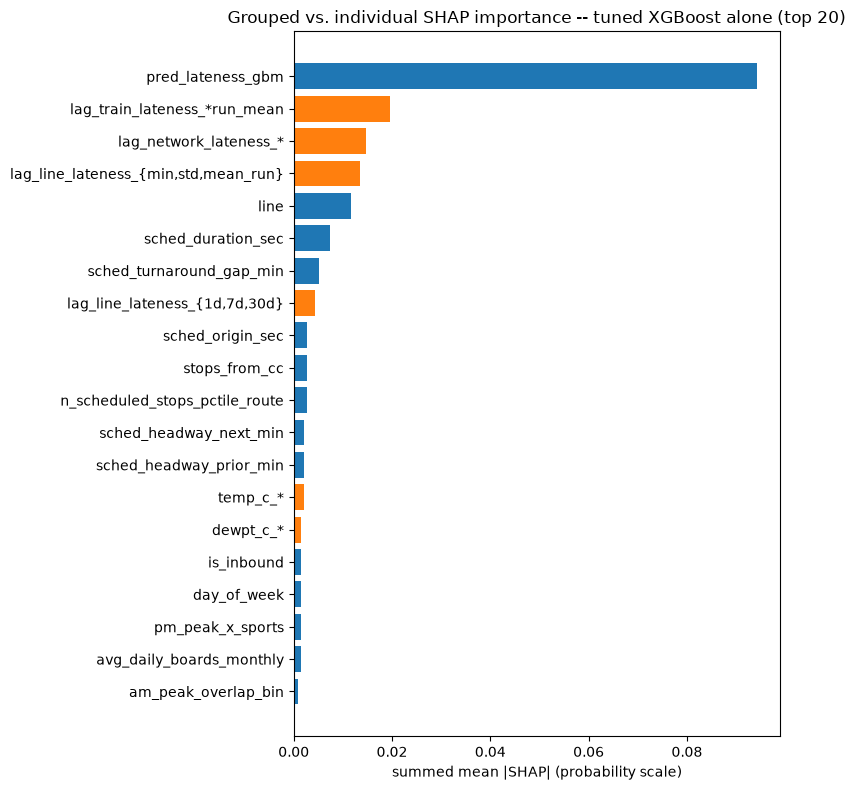

In [6]:
top_n = combined_ranking.head(20).iloc[::-1]
colors = [
    "tab:orange" if n > 1 else "tab:blue" for n in top_n["n_features"]
]
fig, ax = plt.subplots(figsize = (8, 8))
ax.barh(top_n["name"], top_n["importance"], color = colors)
ax.set_xlabel("summed mean |SHAP| (probability scale)")
ax.set_title(
    "Grouped vs. individual SHAP importance -- tuned XGBoost alone "
    "(top 20)"
)
plt.tight_layout()
plt.show()

### Grouped SHAP ranking (matches Appendix B.5)

The report-ready bar chart of these 7 groups lives in `12_figures.ipynb`, loaded from `10_shap_grouped_ranking.parquet` (cached below) -- kept here only as the source of that cache.

In [7]:
B5_GROUPS = [
    "pred_lateness_gbm",
    "lag_train_lateness_*run_mean",
    "lag_network_lateness_*",
    "lag_line_lateness_{min,std,mean_run}",
    "line",
    "sched_turnaround_gap_min",
    "stops_from_cc",
]
b5_ranking = combined_ranking.set_index("name").loc[B5_GROUPS].iloc[::-1]
b5_ranking.to_parquet(f"{BASEPATH}/10_shap_grouped_ranking.parquet")
log_progress("Cached grouped SHAP ranking to 10_shap_grouped_ranking.parquet")

[15:32:11] Cached grouped SHAP ranking to 10_shap_grouped_ranking.parquet


## 2. Regression-GBM decomposition (source of `pred_lateness_gbm`)

The SHAP ranking above finds `pred_lateness_gbm` dominating everything else. This section goes one level deeper: what does the regression GBM itself (the model that predicts lateness and gets stacked in as that one feature) value most, among the raw `GBM_FEATURES`? Since `pred_lateness_gbm` is the classifier's single most important input by a wide margin, this ranking is effectively a decomposition of that dominant feature into the base signals it's actually built from.

SHAP doesn't work on this particular model -- a known bug in how `shap` handles the regression GBM's categorical splits, not something fixable here. Permutation importance is used instead.

Evaluated on the full `test_df` (no complete-case masking, since the regressor handles missing values natively).

In [8]:
X_train_sub_gbm_base, X_test_gbm_base = prep_gbm_matrices(
    train_sub, test_df,
)
y_test_log = np.log1p(test_df["lateness"])

reg_baseline_pred = reg_full.predict(X_test_gbm_base)
reg_baseline_r2 = r2_score(y_test_log, reg_baseline_pred)
reg_baseline_mae = mean_absolute_error(y_test_log, reg_baseline_pred)
log_progress(
    f"Regression-GBM baseline (test, log1p space): "
    f"R2={reg_baseline_r2:.4f}, MAE={reg_baseline_mae:.4f}"
)

[15:32:13] Regression-GBM baseline (test, log1p space): R2=0.3344, MAE=0.6892


Shuffles one `GBM_FEATURES` column at a time in `test_df`, then re-predicts with the already-fitted `reg_full` and records the average drop in R² / rise in MAE across 5 repeats per feature.

Same caveat as the SHAP grouping above: shuffling one feature at a time under-counts a family's true importance when its members are correlated (the four `lag_train_lateness_*run_mean` windows, the three `lag_network_lateness_*` windows, etc.), since the model can partially compensate using the untouched siblings. This doesn't change which families matter -- the dominant ones here are already far ahead of weather, calendar, and ridership.

In [9]:
N_REPEATS = 5
rng = np.random.default_rng(42)
reg_importance_rows = []

_t0 = _time.time()
log_progress(
    f"Running regression-GBM permutation importance "
    f"({len(GBM_FEATURES)} features x {N_REPEATS} repeats)..."
)
# shuffle one feature at a time, re-predict with the already-fitted
# reg_full (no refitting) -- average over 5 repeats to smooth out
# shuffle noise
for i, feature in enumerate(GBM_FEATURES, start = 1):
    r2_drops, mae_rises = [], []
    for _ in range(N_REPEATS):
        shuffled = test_df.copy()
        shuffled[feature] = rng.permutation(shuffled[feature].to_numpy())

        _, X_gbm_shuf = prep_gbm_matrices(train_sub, shuffled)
        p_shuf = reg_full.predict(X_gbm_shuf)

        r2_drops.append(reg_baseline_r2 - r2_score(y_test_log, p_shuf))
        mae_rises.append(
            mean_absolute_error(y_test_log, p_shuf) - reg_baseline_mae
        )

    reg_importance_rows.append({
        "feature": feature,
        "importance_r2": np.mean(r2_drops),
        "importance_mae": np.mean(mae_rises),
    })
    if i % 10 == 0 or i == len(GBM_FEATURES):
        log_progress(
            f"  {i}/{len(GBM_FEATURES)} features done "
            f"({_time.time() - _t0:.1f}s elapsed)"
        )
log_progress(
    f"Regression-GBM permutation importance complete "
    f"({_time.time() - _t0:.1f}s total)"
)

reg_importance_df = (
    pd.DataFrame(reg_importance_rows)
    .sort_values("importance_r2", ascending = False)
    .set_index("feature")
)
reg_importance_df.to_csv(f"{BASEPATH}/10_reg_gbm_importance.csv")
reg_importance_df.head(20)

[15:32:13] Running regression-GBM permutation importance (71 features x 5 repeats)...


[15:33:34]   10/71 features done (81.3s elapsed)


[15:35:00]   20/71 features done (166.5s elapsed)


[15:36:29]   30/71 features done (255.5s elapsed)


[15:37:55]   40/71 features done (341.5s elapsed)


[15:39:26]   50/71 features done (433.2s elapsed)


[15:40:50]   60/71 features done (516.9s elapsed)


[15:42:15]   70/71 features done (602.1s elapsed)


[15:42:23]   71/71 features done (610.4s elapsed)
[15:42:23] Regression-GBM permutation importance complete (610.4s total)


,importance_r2,importance_mae
feature,,
lag_train_lateness_1run_mean,0.098618,0.054130
lag_train_lateness_10run_mean,0.063729,0.033962
lag_line_lateness_min,0.047487,0.028697
sched_turnaround_gap_min,0.046771,0.027761
lag_network_lateness_2hr_mean,0.043044,0.022319
lag_network_lateness_30min_mean,0.028561,0.014137
sched_duration_sec,0.022979,0.015771
lag_train_lateness_3run_mean,0.021661,0.011814
line,0.019893,0.012485


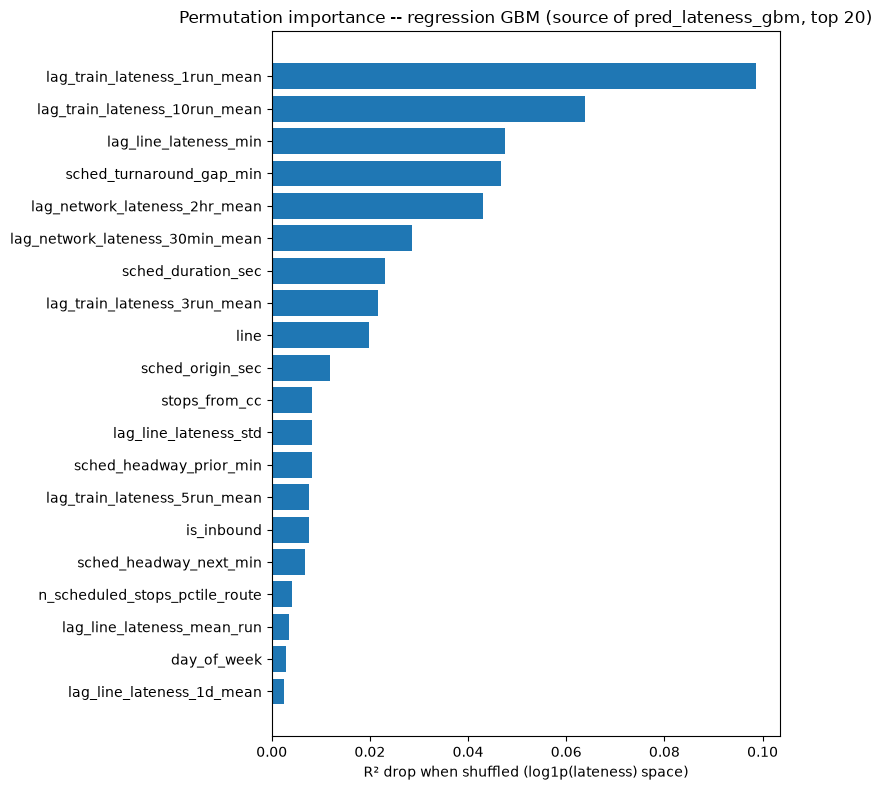

In [10]:
top_n = reg_importance_df.head(20)
fig, ax = plt.subplots(figsize = (8, 8))
ax.barh(top_n.index[::-1], top_n["importance_r2"][::-1])
ax.set_xlabel("R² drop when shuffled (log1p(lateness) space)")
ax.set_title(
    "Permutation importance -- regression GBM "
    "(source of pred_lateness_gbm, top 20)"
)
plt.tight_layout()
plt.show()

The regression GBM's predictions come almost entirely from a small cluster of features, with a sharp drop-off after the top 11: `lag_train_lateness_1run_mean` (that same train's most recent run) accounts for almost double the R² drop of the next feature, `lag_train_lateness_10run_mean`. Below that: `lag_line_lateness_min`, `sched_turnaround_gap_min`, and the two `lag_network_lateness_*` windows sit in a similar mid-tier band, followed by `sched_duration_sec`, `lag_train_lateness_3run_mean`, `line`, `sched_origin_sec`, and `stops_from_cc`. Every weather, calendar, and ridership feature falls below an R² drop of 0.002 -- several are indistinguishable from noise.

Read together with the grouped SHAP ranking above: `pred_lateness_gbm` dominates the classifier's ranking not because it adds new information, but because it's a combination of the same lag-history and schedule features the classifier already has -- momentum on that specific train, plus the line's and network's recent delay state and turnaround pressure. This is why `pred_lateness_gbm`'s dominance is partly definitional, not a uniquely powerful new signal (a caveat the report already carries).

## 3. Late-class SHAP: caught vs. missed

The rankings above measure each feature's contribution to the model's overall accuracy, which mixes both classes. A feature can matter a lot for catching real delays while barely moving the overall average, if it's near zero for the on-time majority (79% of rows) and only kicks in for the late minority. This section asks the late-train question directly: among actually-late trains, what differs (in SHAP terms) between the ones the model catches and the ones it misses?

### SHAP setup -- late-class-oversampled sample

Same SHAP recipe as Section 1, but a different sample on purpose. Section 1 draws a class-proportional sample (about 21% late, matching the test set), for a representative global picture. This section's whole point is the late minority specifically -- a proportional 1000-row sample would only have about 210 late rows. A balanced 1000 rows (500 on-time + 500 late) gives about 2.4x more late-class rows to work with, at the same compute cost.

In [11]:
SHAP_SAMPLE_N_PER_CLASS = 500

# 500 on-time + 500 late, not the real ~79/21 split -- see markdown above
late_pool = test_cc[test_cc["is_otp"] == 0]
otp_pool = test_cc[test_cc["is_otp"] == 1]
shap_sample_late_cc = pd.concat([
    otp_pool.sample(
        n = min(SHAP_SAMPLE_N_PER_CLASS, len(otp_pool)), random_state = 42
    ),
    late_pool.sample(
        n = min(SHAP_SAMPLE_N_PER_CLASS, len(late_pool)), random_state = 42
    ),
])
actual_late_mask = (shap_sample_late_cc["is_otp"] == 0).values
print(
    f"SHAP sample: {shap_sample_late_cc.shape}, "
    f"is_otp rate: {shap_sample_late_cc['is_otp'].mean():.4f} "
    f"(full test_cc rate: {test_cc['is_otp'].mean():.4f}, "
    f"deliberately balanced not proportional)"
)

_, X_shap_late_gbm = prep_gbm_matrices(
    train_sub, shap_sample_late_cc,
    features = STACKED_FEATURES, cat_features = GBM_CAT_FEATURES,
)

SHAP sample: (1000, 108), is_otp rate: 0.5000 (full test_cc rate: 0.7867, deliberately balanced not proportional)


In [12]:
_t0 = _time.time()
log_progress(f"Computing SHAP for {len(shap_sample_late_cc)} rows...")
# reuses Section 1's TreeExplainer, just a different sample
shap_late_margin = class1_shap_values(explainer_gbm, X_shap_late_gbm)
p_late_shap_sample = gbm.predict_proba(X_shap_late_gbm)[:, 1]
# margin-space SHAP -> probability units, same recipe as Section 1
link_deriv_late = (p_late_shap_sample * (1 - p_late_shap_sample))[:, None]
shap_late_df = pd.DataFrame(
    shap_late_margin * link_deriv_late,
    columns = X_shap_late_gbm.columns, index = X_shap_late_gbm.index,
)[STACKED_FEATURES]
log_progress(f"SHAP complete ({_time.time() - _t0:.1f}s)")
print("SHAP done:", shap_late_df.shape)

[15:42:24] Computing SHAP for 1000 rows...


[15:42:25] SHAP complete (0.3s)
SHAP done: (1000, 72)


### Caught vs. missed

Among actually-late rows in this sample, compares average SHAP value (not absolute value) between trains the model correctly flagged and trains it missed, at the default 0.5 threshold.

true positives (caught): 180, false negatives (missed): 320
                                 mean_shap_caught  mean_shap_missed      diff
pred_lateness_gbm                       -0.311636         -0.056152 -0.255484
lag_train_lateness_1run_mean            -0.014290          0.000688 -0.014978
sched_turnaround_gap_min                -0.004360          0.000795 -0.005155
lag_line_lateness_min                   -0.008067         -0.003226 -0.004841
lag_network_lateness_30min_mean         -0.008714         -0.004391 -0.004322
lag_line_lateness_std                   -0.006130         -0.002197 -0.003933
lag_line_lateness_mean_run              -0.004436         -0.002000 -0.002436
is_inbound                              -0.002356         -0.000139 -0.002217
line                                    -0.003296         -0.001360 -0.001936
lag_network_lateness_2hr_mean           -0.008885         -0.007076 -0.001809
sched_duration_sec                      -0.004044         -0.002373 -0.001671
lag_

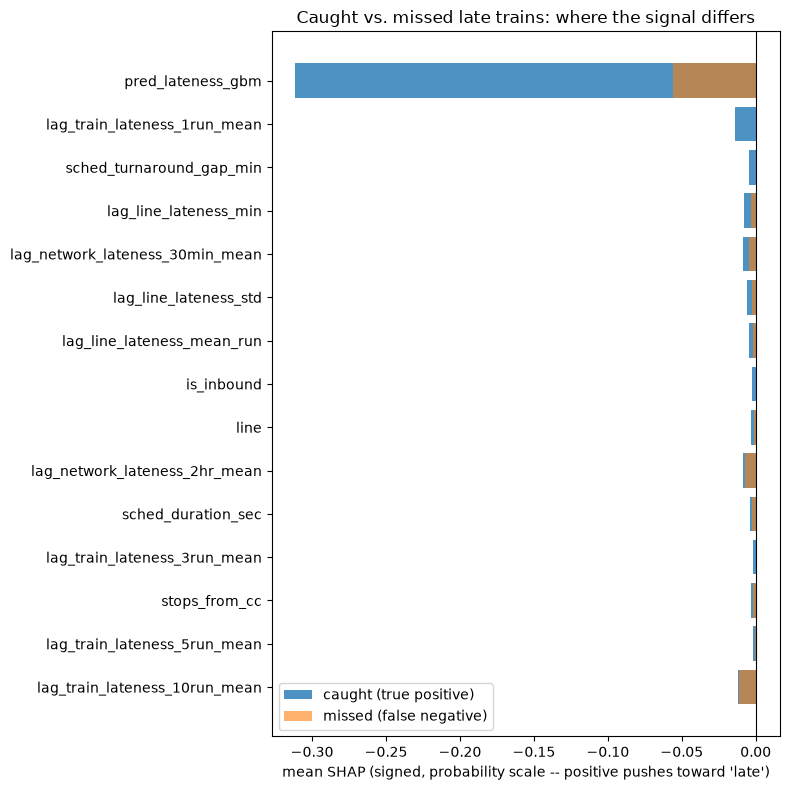

In [13]:
# among actually-late rows: caught = predicted late, missed = predicted
# on-time, both at the default 0.5 threshold
pred_late_sample = (p_late_shap_sample < 0.5)
tp_mask = actual_late_mask & pred_late_sample
fn_mask = actual_late_mask & ~pred_late_sample
print(
    f"true positives (caught): {tp_mask.sum()}, "
    f"false negatives (missed): {fn_mask.sum()}"
)

mean_shap_tp = shap_late_df[tp_mask].mean()
mean_shap_fn = shap_late_df[fn_mask].mean()
tp_vs_fn = pd.DataFrame({
    "mean_shap_caught": mean_shap_tp,
    "mean_shap_missed": mean_shap_fn,
})
tp_vs_fn["diff"] = (
    tp_vs_fn["mean_shap_caught"] - tp_vs_fn["mean_shap_missed"]
)
# sort by |caught - missed| so the biggest gaps come first
tp_vs_fn = tp_vs_fn.reindex(
    tp_vs_fn["diff"].abs().sort_values(ascending = False).index
)
print(tp_vs_fn.head(20))

top_n = tp_vs_fn.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize = (8, 8))
ax.barh(
    top_n.index, top_n["mean_shap_caught"],
    label = "caught (true positive)", alpha = 0.8,
)
ax.barh(
    top_n.index, top_n["mean_shap_missed"],
    label = "missed (false negative)", alpha = 0.6,
)
ax.axvline(0, color = "black", linewidth = 0.8)
ax.set_xlabel(
    "mean SHAP (signed, probability scale -- "
    "positive pushes toward 'late')"
)
ax.set_title("Caught vs. missed late trains: where the signal differs")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Reduced-feature robustness check

The rankings above show importance concentrated in a handful of features -- `pred_lateness_gbm` dominates, then a handful of lag/schedule features, with most weather/calendar features at or below zero importance. This asks the obvious follow-up: if most of the feature set carries little signal, does dropping it hurt the model at all?

Quick and dirty by design -- one model fit, using tuned XGBoost's already-chosen hyperparameters from `09c`, no re-tuning. Feature selection uses `val`, not `test`, since the ranking directly decides which features to drop, and using `test` for that would leak test-set information into a modeling choice before the final evaluation.

Same recipe as Section 1's grouped ranking, but using permutation importance (not SHAP) on `val` instead of `test` -- this needs a cutoff for dropping features, not a ranking of importance, and permutation importance directly answers "does removing this hurt the model."

In [14]:
_cache_path = f"{BASEPATH}/10_val_permutation_importance.parquet"

if os.path.exists(_cache_path):
    log_progress("Loading cached val-set permutation importance...")
    val_importance_df = pd.read_parquet(_cache_path)
# not cached yet -- compute it and save it for next time
else:
    _, X_val_stacked = prep_gbm_matrices(
        train_sub, val_cc,
        features = STACKED_FEATURES, cat_features = GBM_CAT_FEATURES,
    )
    p_val_baseline = gbm.predict_proba(X_val_stacked)[:, 1]
    baseline_val_roc_auc = roc_auc_score(y_val_cc, p_val_baseline)
    print(f"baseline (unpermuted) val roc_auc: {baseline_val_roc_auc:.4f}")

    N_REPEATS = 5
    rng = np.random.default_rng(42)
    val_importance_rows = []

    _t0 = _time.time()
    log_progress(
        f"Running permutation importance on val "
        f"({len(STACKED_FEATURES)} features x {N_REPEATS} repeats)..."
    )
    # shuffle one feature at a time, re-predict with the already-fitted
    # classifier, record the average ROC-AUC drop across 5 repeats
    for i, feature in enumerate(STACKED_FEATURES, start = 1):
        roc_drops = []
        for _ in range(N_REPEATS):
            shuffled = val_cc.copy()
            shuffled[feature] = rng.permutation(shuffled[feature].to_numpy())
            _, X_shuf = prep_gbm_matrices(
                train_sub, shuffled,
                features = STACKED_FEATURES, cat_features = GBM_CAT_FEATURES,
            )
            p_shuf = gbm.predict_proba(X_shuf)[:, 1]
            roc_drops.append(
                baseline_val_roc_auc - roc_auc_score(y_val_cc, p_shuf)
            )
        val_importance_rows.append({
            "feature": feature, "importance_roc_auc": np.mean(roc_drops),
        })
        if i % 10 == 0 or i == len(STACKED_FEATURES):
            log_progress(f"  {i}/{len(STACKED_FEATURES)} features done")

    val_importance_df = pd.DataFrame(val_importance_rows).set_index(
        "feature"
    ).sort_values("importance_roc_auc", ascending = False)
    val_importance_df.to_parquet(_cache_path)
    log_progress(
        f"Permutation importance complete ({_time.time() - _t0:.1f}s total)"
    )

print(val_importance_df.to_string())

[15:42:25] Loading cached val-set permutation importance...
                                 importance_roc_auc
feature                                            
pred_lateness_gbm                      2.507004e-01
line                                   3.227126e-03
lag_train_lateness_1run_mean           2.038156e-03
lag_network_lateness_2hr_mean          1.574502e-03
sched_turnaround_gap_min               1.561315e-03
lag_train_lateness_10run_mean          1.264951e-03
lag_network_lateness_30min_mean        1.025490e-03
sched_duration_sec                     1.021813e-03
stops_from_cc                          6.586698e-04
sched_origin_sec                       6.557641e-04
lag_line_lateness_min                  5.741480e-04
lag_line_lateness_std                  5.570598e-04
sched_headway_prior_min                5.401825e-04
sched_headway_next_min                 5.325472e-04
lag_train_lateness_3run_mean           4.037739e-04
n_scheduled_stops_pctile_route         3.371461e-04
lag_

### Full feature set vs. top 40

Cuts down to the top 40 features by the val-set ranking above (40 chosen ~arbitrarily after an earlier reduction to 55 showed no meaningful difference). Refits tuned XGBoost with the same hyperparameters and compares against the model predictions cached in `09d`. Uses `09d`'s cached `val`/`test` predictions for the baseline so the comparison is exact, vs. a refit.

In [15]:
from sklearn.metrics import (
    brier_score_loss, precision_score, recall_score, f1_score,
    balanced_accuracy_score,
)

baseline_val = pd.read_parquet(f"{BASEPATH}/9d_predictions_val.parquet")
baseline_test = pd.read_parquet(f"{BASEPATH}/9d_predictions_test.parquet")
assert len(baseline_val) == len(val_cc) and len(baseline_test) == len(test_cc)

# scores one set of predictions against the full metric suite
def evaluate(name, y_true, p_otp, threshold = 0.5):
    y_late = 1 - y_true
    p_late = 1 - p_otp
    pred = (p_otp >= threshold).astype(int)
    pred_late = 1 - pred
    return {
        "model": name,
        "accuracy": (pred == y_true).mean(),
        "balanced_accuracy": balanced_accuracy_score(y_true, pred),
        "roc_auc": roc_auc_score(y_true, p_otp),
        "pr_auc_late": average_precision_score(y_late, p_late),
        "precision_late": precision_score(
            y_late, pred_late, zero_division = 0
        ),
        "recall_late": recall_score(y_late, pred_late, zero_division = 0),
        "f1_late": f1_score(y_late, pred_late, zero_division = 0),
        "brier": brier_score_loss(y_true, p_otp),
    }

TOP40_FEATURES = val_importance_df.head(40).index.tolist()
TOP40_CAT_FEATURES = [c for c in GBM_CAT_FEATURES if c in TOP40_FEATURES]

X_train_sub_top40, X_val_top40 = prep_gbm_matrices(
    train_sub, val_df,
    features = TOP40_FEATURES, cat_features = TOP40_CAT_FEATURES,
)
_, X_test_top40 = prep_gbm_matrices(
    train_sub, test_df,
    features = TOP40_FEATURES, cat_features = TOP40_CAT_FEATURES,
)

_t0 = _time.time()
log_progress("Fitting top-40-feature XGBoost (train_sub)...")
gbm_top40 = xgb.XGBClassifier(
    random_state = 42, enable_categorical = True,
    tree_method = "hist", **TUNED_XGB_PARAMS
)
gbm_top40.fit(X_train_sub_top40, train_sub["is_otp"])
p_val_top40 = gbm_top40.predict_proba(X_val_top40)[:, 1][val_mask.values]
p_test_top40 = gbm_top40.predict_proba(X_test_top40)[:, 1][test_mask.values]
log_progress(
    f"Top-40-feature XGBoost fit complete ({_time.time() - _t0:.1f}s)"
)

# side-by-side: full feature set vs. top-40, on both val and test
comparison = pd.DataFrame([
    evaluate(
        f"full feature set ({len(STACKED_FEATURES)} features) -- val",
        baseline_val["is_otp"], baseline_val["p_xgb"],
    ),
    evaluate(
        "top-40 feature set (40 features) -- val", y_val_cc, p_val_top40
    ),
    evaluate(
        f"full feature set ({len(STACKED_FEATURES)} features) -- test",
        baseline_test["is_otp"], baseline_test["p_xgb"],
    ),
    evaluate(
        "top-40 feature set (40 features) -- test", y_test_cc, p_test_top40
    ),
]).set_index("model")
log_progress("10_feature_importance.ipynb complete")
comparison

[15:42:25] Fitting top-40-feature XGBoost (train_sub)...


[15:42:42] Top-40-feature XGBoost fit complete (16.9s)


[15:42:43] 10_feature_importance.ipynb complete


,accuracy,balanced_accuracy,roc_auc,pr_auc_late,precision_late,recall_late,f1_late,brier
model,,,,,,,,
full feature set (72 features) -- val,0.847316,0.649343,0.817925,0.598749,0.729406,0.327627,0.452158,0.113616
top-40 feature set (40 features) -- val,0.847407,0.649782,0.818001,0.599303,0.729151,0.328630,0.453064,0.113539
full feature set (72 features) -- test,0.832162,0.662257,0.804500,0.610259,0.705675,0.365902,0.481921,0.124046
top-40 feature set (40 features) -- test,0.832210,0.662097,0.804693,0.610852,0.706395,0.365380,0.481636,0.123965
